In [25]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

## PART 1 — Regression Algorithm

**Task 1: Linear Regression**

1. Select a numerical target variable.
2. Split the data into training and testing sets.
3. Train a Linear Regression model using scikit-learn.
4. Make predictions on test data.
5. Plot Actual vs Predicted values.


In [9]:
df = pd.read_csv('ecommerce_sales_analytics_5000.csv')
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 593.2 KB


In [11]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day

df.drop(columns=['order_id', 'customer_id', 'order_date'], inplace=True)
df.head()

,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,order_year,order_month,order_day
0,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,1
1,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,2
2,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,2022,1,3
3,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,4
4,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,5


In [12]:
df.describe()

,quantity,unit_price,discount,delivery_days,customer_rating,revenue,order_year,order_month,order_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148,2028.352800,6.430600,15.708400
std,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219,3.954827,3.427584,8.804753
min,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000,2022.000000,1.000000,1.000000
25%,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500,2025.000000,3.000000,8.000000
50%,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000,2028.000000,6.000000,16.000000
75%,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000,2032.000000,9.000000,23.000000
max,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000,2035.000000,12.000000,31.000000


In [13]:
df.isnull().sum()

product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
order_year          0
order_month         0
order_day           0
dtype: int64

In [15]:
categorical_columns = [col for col in df.columns if df[col].dtype == 'str']
numerical_columns = ['quantity', 'unit_price', 'discount', 
                        'delivery_days', 'customer_rating', 
                        'order_year', 'order_month', 'order_day']

print("Categorical columns: ", categorical_columns)
print("Numerical columns: ", numerical_columns)

Categorical columns:  ['product_category', 'region', 'payment_method']
Numerical columns:  ['quantity', 'unit_price', 'discount', 'delivery_days', 'customer_rating', 'order_year', 'order_month', 'order_day']


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [19]:
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessing_pipeline = ColumnTransformer([
    ('num_pipeline', num_pipeline, numerical_columns),
    ('cat_pipeline', cat_pipeline, categorical_columns)
])

preprocessing_pipeline

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...), ('cat_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` an

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [21]:
X = df[numerical_columns + categorical_columns]
y = df['revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((4000, 11), (1000, 11), (4000,), (1000,))

In [22]:
lr_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['quantity','unit_price','discount',...,'product_category','region', 'payment_method']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...), ('cat_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically pass

## PART 2 — Regression Metrics

**Task 2: Regression Evaluation Metrics**
Using predictions from Linear Regression, calculate:

1. Mean Absolute Error (MAE)
2. Mean Squared Error (MSE)
3. Root Mean Squared Error (RMSE)
   Print and interpret each metric briefly.

In [27]:
y_pred = lr_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")


Mean Squared Error: 87757.96028563833
R-squared: 0.8697498356543487
Mean Absolute Error: 219.33117869736884
Root Mean Squared Error: 296.2397007250013


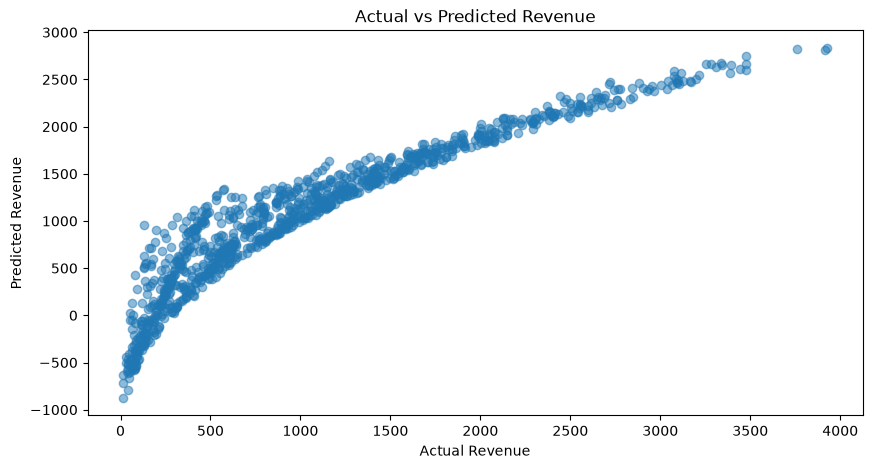

In [28]:
# plot actual vs predicted values
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title('Actual vs Predicted Revenue')
plt.show()

**Task 2 — quick interpretation**

1. **MAE (Mean Absolute Error)**  
   On average the model is off by about that many units of revenue. Like if MAE is ~200, predictions are usually wrong by around ₹200 either way. Easy to understand because it’s just average distance from actual.

2. **MSE (Mean Squared Error)**  
   Same idea as MAE but it squares the errors first, so big mistakes get punished more. That’s why MSE is usually a bigger number and harder to read directly.

3. **RMSE (Root Mean Squared Error)**  
   Basically MSE but brought back to the same scale as revenue (square root). I usually look at RMSE more than MSE because it’s in “revenue units” again. Lower = better.

Overall the model isn’t perfect (scatter plot isn’t a straight line) but RMSE/MAE tell you roughly how far off you are on test data. Still getting used to which metric to trust — MAE feels simpler, RMSE catches when the model really messes up on a few orders.

## PART 3 — Classification Algorithms

**Task 3: Logistic Regression**

1. Select a classification target variable.
2. Split data into training and testing sets.
3. Train a Logistic Regression model.
4. Make predictions.


In [33]:
customer = pd.read_csv('telecom_churn.csv') # data link https://www.kaggle.com/datasets/barun2104/telecom-churn

In [34]:
customer.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [35]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [36]:
customer.shape

(3333, 11)

In [37]:
customer.isnull().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

In [32]:
customer.columns

Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='str')

In [38]:
numerical_columns = ['AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins']

# no categorical data
numperical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

preprocessing_pipeline = ColumnTransformer([
    ('num_pipeline', numperical_pipeline, numerical_columns)
])

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [40]:
X = customer[numerical_columns]
y = customer['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2666, 10), (667, 10), (2666,), (667,))

In [41]:
logistic_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', LogisticRegression())
])

logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['AccountWeeks','ContractRenewal','DataPlan',...,'MonthlyCharge', 'OverageFee','RoamMins']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [42]:
y_pred = logistic_pipeline.predict(X_test)

In [43]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

print(classification_report(y_test, y_pred))

confusion_matrix(y_test, y_pred)

Accuracy: 0.8590704647676162
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       566
           1       0.62      0.18      0.28       101

    accuracy                           0.86       667
   macro avg       0.75      0.58      0.60       667
weighted avg       0.83      0.86      0.82       667



array([[555,  11],
       [ 83,  18]])

**Task 4: Naive Bayes Classifier**

1. Train a Naive Bayes model (GaussianNB).
2. Predict on test data.
3. Compare results with Logistic Regression.

In [44]:
from sklearn.naive_bayes import GaussianNB

In [45]:
gnb_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', GaussianNB())
])

gnb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['AccountWeeks','ContractRenewal','DataPlan',...,'MonthlyCharge', 'OverageFee','RoamMins']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [46]:
y_pred_gnb = gnb_pipeline.predict(X_test)
accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
print(f"Accuracy: {accuracy_gnb}")

print(classification_report(y_test, y_pred_gnb))

confusion_matrix(y_test, y_pred_gnb)

Accuracy: 0.8395802098950524
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       566
           1       0.46      0.36      0.40       101

    accuracy                           0.84       667
   macro avg       0.68      0.64      0.65       667
weighted avg       0.82      0.84      0.83       667



array([[524,  42],
       [ 65,  36]])

In [47]:
# Compare results with Logistic Regression
print("Logistic Regression accuracy:", accuracy)
print("Naive Bayes accuracy:", accuracy_gnb)

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [accuracy, accuracy_gnb]
})
print(comparison)

Logistic Regression accuracy: 0.8590704647676162
Naive Bayes accuracy: 0.8395802098950524
                 Model  Accuracy
0  Logistic Regression   0.85907
1          Naive Bayes   0.83958


In [48]:
print("--- Logistic Regression ---")
print(classification_report(y_test, y_pred))

print("--- Naive Bayes ---")
print(classification_report(y_test, y_pred_gnb))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       566
           1       0.62      0.18      0.28       101

    accuracy                           0.86       667
   macro avg       0.75      0.58      0.60       667
weighted avg       0.83      0.86      0.82       667

--- Naive Bayes ---
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       566
           1       0.46      0.36      0.40       101

    accuracy                           0.84       667
   macro avg       0.68      0.64      0.65       667
weighted avg       0.82      0.84      0.83       667



**Task 5: K-Nearest Neighbors (KNN)**

1. Train a KNN classifier with at least 3 different values of k.
2. Observe accuracy changes for different k values.
3. Select the best-performing k.

In [57]:
from sklearn.neighbors import KNeighborsClassifier

In [59]:
# re-import in case an old cell overwrote these names in the kernel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

k_values = [3, 5, 7]

metrics_list = []
for k in k_values:
    knn_pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])
    knn_pipeline.fit(X_train, y_train)
    y_pred = knn_pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    metrics_list.append({
        'k': k,
        'accuracy': acc
    })

print(metrics_list)


[{'k': 3, 'accuracy': 0.896551724137931}, {'k': 5, 'accuracy': 0.9055472263868066}, {'k': 7, 'accuracy': 0.9085457271364318}]


In [60]:
pd.DataFrame(metrics_list)

,k,accuracy
0,3,0.896552
1,5,0.905547
2,7,0.908546


In [61]:
# best k value
best_k = pd.DataFrame(metrics_list).sort_values(by='accuracy', ascending=False).iloc[0]['k']
print(f"Best k value: {best_k}")

Best k value: 7.0


In [63]:
best_k_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', KNeighborsClassifier(n_neighbors=best_k.astype(int)))
])

best_k_pipeline.fit(X_train, y_train)
y_pred_best_k = best_k_pipeline.predict(X_test)

## PART 4 — Classification Metrics

**Task 6 — Evaluation Metrics for Classification**
For Logistic Regression, Naive Bayes, and KNN, compute:

1. Accuracy
2. Precision
3. Recall
4. F1-score

Display results using:

- Classification report
- Confusion matrix

In [64]:
print("--- Logistic Regression ---")
print(classification_report(y_test, y_pred))

print("--- Naive Bayes ---")
print(classification_report(y_test, y_pred_gnb))

print("--- KNN ---")
print(classification_report(y_test, y_pred_best_k))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       566
           1       0.90      0.45      0.60       101

    accuracy                           0.91       667
   macro avg       0.90      0.72      0.77       667
weighted avg       0.91      0.91      0.90       667

--- Naive Bayes ---
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       566
           1       0.46      0.36      0.40       101

    accuracy                           0.84       667
   macro avg       0.68      0.64      0.65       667
weighted avg       0.82      0.84      0.83       667

--- KNN ---
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       566
           1       0.90      0.45      0.60       101

    accuracy                           0.91       667
   macro avg       0.90      0.72      0.77       667
weighted avg  

## PART 5 — Model Behavior & Learning Concepts

**Task 7: Overfitting & Underfitting**

1. Train a model with:
   - Very simple configuration (underfitting)
   - Very complex configuration (overfitting)
2. Compare:
   - Training accuracy
   - Testing accuracy

Explain the observed behavior.

In [65]:
simple_k_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', KNeighborsClassifier(n_neighbors=1))
])

simple_k_pipeline.fit(X_train, y_train)
y_pred_simple_k = simple_k_pipeline.predict(X_test)

In [73]:
complex_k_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', KNeighborsClassifier(n_neighbors=100))
])

complex_k_pipeline.fit(X_train, y_train)
y_pred_complex_k = complex_k_pipeline.predict(X_test)

In [74]:
print("--- Simple KNN ---")
print("training accuracy:", accuracy_score(y_train, simple_k_pipeline.predict(X_train)))
print("testing accuracy:", accuracy_score(y_test, y_pred_simple_k))
print(classification_report(y_test, y_pred_simple_k))

print("--- Complex KNN ---")
print("training accuracy:", accuracy_score(y_train, complex_k_pipeline.predict(X_train)))
print("testing accuracy:", accuracy_score(y_test, y_pred_complex_k))
print(classification_report(y_test, y_pred_complex_k))

--- Simple KNN ---
training accuracy: 1.0
testing accuracy: 0.8665667166416792
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       566
           1       0.56      0.55      0.56       101

    accuracy                           0.87       667
   macro avg       0.74      0.74      0.74       667
weighted avg       0.87      0.87      0.87       667

--- Complex KNN ---
training accuracy: 0.8619654913728432
testing accuracy: 0.8530734632683659
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       566
           1       1.00      0.03      0.06       101

    accuracy                           0.85       667
   macro avg       0.93      0.51      0.49       667
weighted avg       0.87      0.85      0.79       667



**Task 7 — what I saw**

Used KNN with `k=1` (too flexible / overfitting) and `k=100` (too simple / underfitting).

**k=1 (overfitting)**
- Training accuracy: **1.0**
- Testing accuracy: **~0.87**
- Train is perfect but test is lower — big gap. Model basically memorized training data and doesn’t generalize as well.

**k=100 (underfitting)**
- Training accuracy: **~0.86**
- Testing accuracy: **~0.85**
- Both are lower and close together. Model is too “dumb” / smooth — not learning the patterns well enough.

**Task 8: Bias & Variance (Conceptual)**
Answer the following:

1. What is bias in ML models?
2. What is variance?
3. How do bias and variance relate to underfitting and overfitting?
4. How can we reduce overfitting?


**Task 8 — answers**

1. **Bias**  
   Bias is when the model is too simple and keeps making the same kind of mistake. It doesn’t really capture the pattern in the data — like our k=100 KNN that did meh on both train and test.

2. **Variance**  
   Variance is when the model is too sensitive to the training data. Small changes in training can change predictions a lot. k=1 KNN had this — 100% train accuracy but test dropped.

3. **Bias vs variance → under/overfitting**  
   - High bias + low variance → **underfitting** (k=100, both accuracies low-ish and close)  
   - Low bias + high variance → **overfitting** (k=1, train perfect, test worse)  
   Basically underfit = too dumb, overfit = memorizing.

4. **How to reduce overfitting**  
   - pick simpler model / increase k for KNN  
   - get more data if you can  
   - regularization (for logistic regression etc.)  
   - train/test split so you’re not judging on training only  
   - cross-validation to pick better hyperparams  

   From Task 5, k=5 or 7 worked better than k=1 for me.